# 3.4 总结：MMoE 与 PLE 多目标

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

读取本章节每个独立算法 Notebook 的实际结果产物，在统一口径下比较和选型。

## Setup

默认 `smoke` 档使用仓库内固定版本的 GroupLens **MovieLens latest-small** 真实行为子集，CPU 可重复执行；`full` 档只扩大真实数据规模与训练配置，不切换到合成数据。数据包含真实匿名用户、电影、评分和时间戳；实验只做确定性截取与任务重构，不随机制造交互、标签或行为序列。原始许可与引用保存在 `data/ml-latest-small/README.txt`。

**主要资料：** MMoE · PLE 原始论文

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "smoke")
PROFILE = os.environ["RECSYS_PROFILE"]
from recsys_lab.data import load_movielens, movielens_provenance
real_ratings, real_movies = load_movielens()
REAL_DATASET = movielens_provenance(real_ratings)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 26732, 'users_used': 120, 'items_used': 600, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0}}


## 开篇回顾

本章节固定为 **开篇导读 → 独立算法教程 → 结果总结**。每篇算法 Notebook 都包含论文、数学、数据、训练、推理、测试与讨论；本页不重新训练，也不手填数字。

MMoE 为任务选择共享专家；PLE 再隔离任务专属专家。必须逐任务报告，避免平均指标掩盖跷跷板，并检查专家利用率与负迁移。

## Results

读取 results 目录。若缺文件，请先按章节顺序执行算法 Notebook。

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
result_dir=ROOT/'results'/'chapter_3_4'; files=sorted(result_dir.glob('*.json'))
assert len(files)==2,f'期望 2 个结果，实际 {[p.name for p in files]}'
records=[]
for path in files: records.extend(json.loads(path.read_text(encoding='utf-8'))['records'])
comparison=pd.DataFrame(records); display(comparison.round(4)); print('数据来源:',[p.name for p in files])

,algorithm,primary_metric,primary_value,secondary_metric,secondary_value,baseline_metric,baseline_value,framework,source_notebook,dataset,randomly_fabricated_rows
0,MMoE 多目标学习,click_auc,0.5537,conversion_auc,0.5144,None,None,torch_rechub.models.multi_task.MMOE,3_4_1_mmoe,MovieLens latest-small,0
1,PLE 渐进式专家抽取,click_auc,0.5380,conversion_auc,0.5135,None,None,torch_rechub.models.multi_task.PLE,3_4_2_ple,MovieLens latest-small,0


数据来源: ['3_4_1_mmoe.json', '3_4_2_ple.json']


/tmp/ipykernel_8648/253447002.py:6: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_8648/253447002.py:6: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_8648/253447002.py:6: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_8648/253447002.py:6: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_8648/253447002.py:6: UserWarning: Glyph 20064 (\N{CJK UNIFIED IDEOGRAPH-4E60}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_8648/253447002.py:6: UserWarning: Glyph 28176 (\N{CJK UNIFIED IDEOGRAPH-6E10}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_8648/253447002.py:6

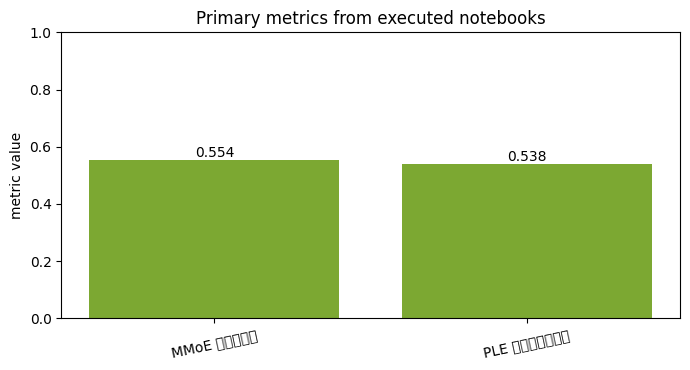

In [3]:
fig,ax=plt.subplots(figsize=(max(7,len(comparison)*1.5),3.8))
bars=ax.bar(comparison.algorithm,comparison.primary_value,color='#7ca832')
ax.set(title='Primary metrics from executed notebooks',ylabel='metric value',ylim=(0,max(1.0,comparison.primary_value.max()*1.18)))
ax.tick_params(axis='x',rotation=12)
for bar,value in zip(bars,comparison.primary_value): ax.text(bar.get_x()+bar.get_width()/2,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show()

## Takeaways

MMoE 为任务选择共享专家；PLE 再隔离任务专属专家。必须逐任务报告，避免平均指标掩盖跷跷板，并检查专家利用率与负迁移。

先固定业务阶段和候选口径，再比较主指标、辅助指标、baseline 与系统成本。smoke 数值用于代码回归和学习，不能跨数据或跨公司宣称优劣。

## Checks

In [4]:
assert len(comparison)==2
assert comparison.source_notebook.nunique()==2
assert comparison.primary_value.between(0,1).all()
print('PASS：总结完全来自独立 Notebook 的执行产物。')

PASS：总结完全来自独立 Notebook 的执行产物。


## Next Steps

在相同完整数据、时间切分、负样本和候选集上重跑；加入效果—延迟—成本三维表，再决定是否进入线上 A/B。